### 🤖 What are Multi-Agent RAG Systems?
A Multi-Agent RAG System splits the RAG pipeline into multiple specialized agents — each responsible for a specific role — and enables them to collaborate on a single query or task.

#### 1. 📋 Multi-Agent Network RAG System with LangGraph
Project Overview

A beginner-friendly Retrieval-Augmented Generation (RAG) system that uses a multi-agent architecture to intelligently answer questions from your documents. Built with LangGraph v0.3 for workflow orchestration and OpenAI for language understanding.

What It Does

Transforms your documents (PDFs, text files) into a searchable knowledge base that can answer questions intelligently using AI. Simply upload documents and ask questions in natural language - the system finds relevant information and generates comprehensive answers.
Key Features

- 📚 Multi-Format Support: Handles PDF and text documents
- 🤖 3-Agent Architecture: Specialized agents for document processing, retrieval, and answer generation
- 🔍 Smart Search: Vector-based semantic search finds relevant information
- 💬 Natural Language Q&A: Ask questions in plain English


In [1]:
import os 
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

# LLM Model
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")
llm

c:\Users\heman\Desktop\05 Ultimate RAG Bootcamp Using Langchain,LangGraph and Langsmith by Krish Naik\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ChatOpenAI(client=<openai.resources.chat.completions.completions.Completions object at 0x000002A541EFB8C0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000002A54238C440>, root_client=<openai.OpenAI object at 0x000002A541EF96A0>, root_async_client=<openai.AsyncOpenAI object at 0x000002A54238C1A0>, model_name='gpt-4o-mini', model_kwargs={}, openai_api_key=SecretStr('**********'))

In [2]:
# Tavily Tool Implimentation
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

from langchain_tavily import TavilySearch
tavily_tool = TavilySearch(max_results=5)
tavily_tool

TavilySearch(max_results=5, api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None))

In [3]:
# generic function to create a retrieval tool
from langchain.document_loaders import TextLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain.agents import Tool

def make_retriever_tool_from_text(file, name, desc):
    # laod docs
    loader = TextLoader(file, encoding="utf-8")
    docs = loader.load()
    
    # split into chunks 
    splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
    chunks = splitter.split_documents(docs)
    
    # embeddings
    embeddings = OpenAIEmbeddings()
    
    # vectorstore
    vs = FAISS.from_documents(chunks, embeddings)
    
    # retriever
    retriever = vs.as_retriever()

    # function
    def tool_func(query:str)->str:
        print(f"📚 Using tool: {name}")
        results = retriever.invoke(query)
        return "\n\n".join(doc.page_content for doc in results)
    
    return Tool(name=name, description=desc, func=tool_func)


internal_tool_1 = make_retriever_tool_from_text("research.txt", "InternalResearchNotes", "Search internal research notes for experimental results")
internal_tool_1


Tool(name='InternalResearchNotes', description='Search internal research notes for experimental results', func=<function make_retriever_tool_from_text.<locals>.tool_func at 0x000002A520834220>)

In [4]:
from langchain_core.messages import BaseMessage
from langgraph.graph import END

# generic function to get the next node
def get_next_node(last_message: BaseMessage, goto: str):
    if "FINAL ANSWER" in last_message.content:
        # Any agent decided the work is done
        return END
    
    # otherwise, keep going
    return goto

In [5]:
# generic function to create a system prompt
def make_system_prompt(suffix: str) -> str:
    return (
        "You are a helpful AI assistant, collaborating with other assistants."
        " Use the provided tools to progress towards answering the question."
        " If you are unable to fully answer, that's OK, another assistant with different tools "
        " will help where you left off. Execute what you can to make progress."
        " If you or any of the other assistants have the final answer or deliverable,"
        " prefix your response with FINAL ANSWER so the team knows to stop."
        f"\n{suffix}"
    )

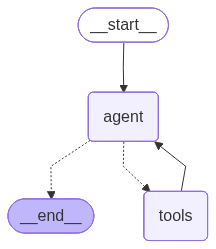

In [6]:
# Reaearch agent and node
from langgraph.prebuilt import create_react_agent

research_agent = create_react_agent(
    llm,
    tools=[internal_tool_1, tavily_tool],
    prompt=make_system_prompt("You can only do research. Use the tool that you are binded with, you can use both of them" \
    " You are working with a content writer colleague.")
)

research_agent

In [7]:
from langchain_core.messages import  HumanMessage 
from langgraph.graph import MessagesState, END
from langgraph.types import Command
from typing import Literal


# Reaearch node
def research_node(state: MessagesState)-> Command[Literal["blog_generator", END]]:
    
    result = research_agent.invoke(state)
    goto = get_next_node(result["messages"][-1], "blog_generator")

    # wrap in a human message, as not all providers allow
    # AI message at the last position of the input messages list
    result["messages"][-1] = HumanMessage(
        content=result["messages"][-1].content, name="researcher"
    )
    
    return Command(
        update={
            # share internal message history of research agent with other agents
            "messages": result["messages"],
        },
        goto=goto,
    )


In [8]:
from langchain_core.messages import HumanMessage
from langgraph.prebuilt import create_react_agent
from langgraph.graph import MessagesState, END
from langgraph.types import Command

# Blog write agent
blog_agent = create_react_agent(
    llm,
    tools=[],
    prompt=make_system_prompt(
        "You can only write a detailed blog. You are working with a researcher colleague."
    )
)


def blog_node(state: MessagesState) -> Command[Literal["researcher", END]]:
    
    result = blog_agent.invoke(state)
    goto = get_next_node(result["messages"][-1], "researcher")
    # wrap in a human message, as not all providers allow
    # AI message at the last position of the input messages list
    result["messages"][-1] = HumanMessage(
        content=result["messages"][-1].content, name="blog_generator"
    )
    
    return Command(
        update={
            # share internal message history of chart agent with other agents
            "messages": result["messages"],
        },
        goto=goto,
    )

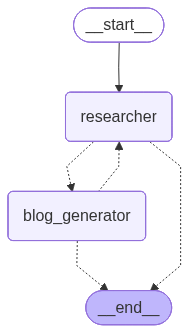

In [9]:
from langgraph.graph import StateGraph, START

# Build the graph
graph = StateGraph(MessagesState)

# Nodes
graph.add_node("researcher", research_node)
graph.add_node("blog_generator", blog_node)

# Edges
graph.add_edge(START, "researcher")

# Compile
workflow = graph.compile()
workflow

In [10]:
query = {"messages": "Write a detailed blog on transformer variants in production deployments"}

result = workflow.invoke(query)
result

📚 Using tool: InternalResearchNotes


{'messages': [HumanMessage(content='Write a detailed blog on transformer variants in production deployments', additional_kwargs={}, response_metadata={}, id='7241e8ba-4c6a-44b0-97b7-cd1a6ce65a9d'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_sEPB73Sles7sQ3S70qD8TmGe', 'function': {'arguments': '{"query":"transformer variants in production deployments","search_depth":"advanced"}', 'name': 'tavily_search'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 1424, 'total_tokens': 1450, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1280}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_51db84afab', 'id': 'chatcmpl-CHnCR0ycJIFeGZkqtD275M6EX8xPK', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='ru

In [11]:
print(result["messages"][-1].content)

FINAL ANSWER

## Transformer Variants in Production Deployments

The advent of transformer architecture has revolutionized various fields such as natural language processing (NLP), computer vision, and more. As organizations seek to maximize the benefits of these models in production settings, various transformer variants have surfaced—each with unique features designed to enhance efficiency, reduce latencies, and tackle deployment challenges. In this blog post, we will explore several transformer variants, their deployment considerations, and the best practices for ensuring robust performance in real-world scenarios.

### 1. Understanding Transformer Architecture

At its core, a transformer comprises an encoder-decoder structure utilizing self-attention mechanisms to process input sequences. Introduced in the landmark paper "Attention is All You Need" by Vaswani et al., transformers allow for parallelization, enabling the processing of entire sequences simultaneously—a significant dep